# Internship Program Analysis

## Problem Statement

Internship programs involve multiple departments, mentors, and participants, making it challenging to monitor enrollment, track intern progress, and evaluate overall program performance. Analyzing internship data helps identify completion trends, dropout patterns, department participation, internship duration, and mentor engagement. These insights support data-driven decision-making and help improve future internship programs.

## Project Objectives

The main objectives of this analysis are to:

- Analyze internship enrollment trends.
- Calculate internship completion and dropout rates.
- Examine department-wise participation.
- Analyze internship duration and completion progress.
- Evaluate mentor interactions.
- Generate meaningful visualizations and insights.

## Dataset Information

This dataset contains internship records for the year **2025**. It includes information about interns, educational background, departments, internship tracks, mentors, enrollment dates, internship progress, task submissions, mentor interactions, and completion status.

The dataset is used to perform exploratory data analysis (EDA) to identify patterns and generate insights related to internship program performance.

### Dataset Summary

| Attribute | Details |
|-----------|---------|
| **Dataset Name** | Internship Program Dataset |
| **Time Period** | 2025 |
| **File Format** | CSV (.csv) |
| **Number of Records** | 70,000 |
| **Number of Features** | 17 |
| **Data Type** | Structured Tabular Data |
| **Primary Goal** | Internship Program Analysis |

### Dataset Features

| Feature | Description |
|----------|-------------|
| **Intern_ID** | Unique identifier assigned to each intern |
| **Intern_Name** | Name of the intern |
| **Gender** | Gender of the intern |
| **Age** | Age of the intern |
| **City** | City of residence |
| **Education** | Educational qualification |
| **Institute** | Educational institute |
| **Department** | Internship department |
| **Internship_Track** | Internship specialization |
| **Mentor_ID** | Unique identifier assigned to each mentor |
| **Mentor_Name** | Name of the assigned mentor |
| **Enrollment_Date** | Internship enrollment date |
| **Internship_Duration_Weeks** | Total internship duration |
| **Weeks_Completed** | Number of weeks completed |
| **Tasks_Submitted** | Number of submitted tasks |
| **Mentor_Interactions** | Total mentor interactions |
| **Status** | Internship completion status |

## Import Required Libraries

This project uses Python libraries for data manipulation, analysis, and visualization. Pandas and NumPy are used for handling and processing data, while Matplotlib and Seaborn are used to create clear and informative visualizations that help identify patterns and trends within the dataset.

In [1]:
# Import Pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical computations
import numpy as np

# Import Matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

## Load the Dataset

In this section, the internship dataset is loaded into a Pandas DataFrame. The `Enrollment_Date` column is converted to a datetime format to enable accurate date-based analysis and visualization throughout the project.

In [2]:
# Load the dataset
internship_df = pd.read_csv("../data/raw/internship_program_2025.csv")

# Convert the Enrollment_Date column to datetime format
internship_df["Enrollment_Date"] = pd.to_datetime(internship_df["Enrollment_Date"])

## Dataset Overview

This section provides an overview of the dataset to verify its structure, understand the available features, and ensure that the data has been loaded correctly before performing further analysis.

In [3]:
# Display the first five records
internship_df.head()

,Intern_ID,Intern_Name,Gender,Age,City,Education,Institute,Department,Internship_Track,Mentor_ID,Mentor_Name,Enrollment_Date,Internship_Duration_Weeks,Weeks_Completed,Tasks_Submitted,Mentor_Interactions,Status
0,INT00001,Ahmed Shafiq,Male,20,Gujrat,BS Computer Science,FAST National University,Other Internships,Data Science,MEN026,Hassan Iqbal,2025-05-01,8,6,1,15,Dropped
1,INT00002,Waqas Javed,Male,25,Islamabad,BS Artificial Intelligence,University of Central Punjab,Graphic Design,Figma,MEN016,Noor Fatima,2025-01-26,8,8,7,17,Completed
2,INT00003,Rehan Ansari,Male,20,Chiniot,DAE (Computer Information Technology),Punjab Polytechnic Institute,App Development,Android,MEN020,Huzaifa Waheed,2025-07-18,8,7,3,13,Dropped
3,INT00004,Salman Pirzada,Male,22,Mardan,BS Computer Engineering,University of Engineering and Technology (UET),Backend Development,PHP,MEN001,Ahmed Khan,2025-04-03,8,8,8,18,Completed
4,INT00005,Salman Gilani,Male,23,Mardan,BS Computer Science,University of Engineering and Technology (UET),App Development,Flutter,MEN017,Daniyal Ahmed,2025-06-18,8,8,6,18,Completed


In [4]:
# Display dataset information
internship_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Intern_ID                  70000 non-null  str           
 1   Intern_Name                70000 non-null  str           
 2   Gender                     70000 non-null  str           
 3   Age                        70000 non-null  int64         
 4   City                       70000 non-null  str           
 5   Education                  70000 non-null  str           
 6   Institute                  70000 non-null  str           
 7   Department                 70000 non-null  str           
 8   Internship_Track           70000 non-null  str           
 9   Mentor_ID                  70000 non-null  str           
 10  Mentor_Name                70000 non-null  str           
 11  Enrollment_Date            70000 non-null  datetime64[us]
 12  Internship_Dura

### Observation

- The dataset contains **70,000 records** and **17 features**.
- All columns contain complete records with no missing values.
- The dataset includes categorical, numerical, and datetime features.
- The `Enrollment_Date` column has been successfully converted to the datetime data type.
- The dataset is ready for data quality assessment and exploratory data analysis.

## Data Validation

Before starting the exploratory data analysis, the dataset is validated to ensure that it follows the expected business rules. This includes checking categorical values, identifying duplicate records, and verifying that numerical values fall within valid ranges.

In [5]:
# Check for duplicate records
print("Duplicated Records: ",internship_df.duplicated().sum())

Duplicated Records:  0


In [6]:
# Display unique values in important categorical columns
categorical_columns = [
    "Gender",
    "City",
    "Education",
    "Institute",
    "Department",
    "Internship_Track",
    "Status"
]

for column in categorical_columns:
    print("=" * 100)
    print(f"{column} ({internship_df[column].nunique()} Unique Values)")
    print("-" * 100)

    values = sorted(internship_df[column].unique())

    for value in values:
        print(f"• {value}")

    print()



Gender (2 Unique Values)
----------------------------------------------------------------------------------------------------
• Female
• Male

City (40 Unique Values)
----------------------------------------------------------------------------------------------------
• Abbottabad
• Bahawalpur
• Bannu
• Chiniot
• Dera Ghazi Khan
• Faisalabad
• Gujranwala
• Gujrat
• Gwadar
• Hyderabad
• Islamabad
• Jacobabad
• Jhang
• Karachi
• Kasur
• Khushab
• Kohat
• Lahore
• Larkana
• Mardan
• Mingora
• Mirpur Khas
• Multan
• Muzaffarabad
• Nawabshah
• Nowshera
• Okara
• Pakpattan
• Peshawar
• Quetta
• Rahim Yar Khan
• Rawalpindi
• Sahiwal
• Sargodha
• Sheikhupura
• Sialkot
• Sukkur
• Turbat
• Vehari
• Wah Cantt

Education (19 Unique Values)
----------------------------------------------------------------------------------------------------
• BBA
• BS Artificial Intelligence
• BS Computer Engineering
• BS Computer Science
• BS Cyber Security
• BS Data Analytics
• BS Data Science
• BS Information Tech

### Validate Business Rules

The following checks verify that the numerical values satisfy the expected business rules defined for the internship program.

In [7]:
# Validate internship duration

internship_df["Internship_Duration_Weeks"].value_counts()

Internship_Duration_Weeks
8    70000
Name: count, dtype: int64

In [8]:
# Validate completed weeks

print(f"Minimum Weeks Completed : {internship_df['Weeks_Completed'].min()}")

print(f"Maximum Weeks Completed : {internship_df['Weeks_Completed'].max()}")

Minimum Weeks Completed : 1
Maximum Weeks Completed : 8


In [9]:
# Validate submitted tasks

print(f"Minimum Tasks Submitted : {internship_df['Tasks_Submitted'].min()}")

print(f"Maximum Tasks Submitted : {internship_df['Tasks_Submitted'].max()}")

Minimum Tasks Submitted : 0
Maximum Tasks Submitted : 8


In [10]:
# Validate age values

print(f"Minimum Age : {internship_df['Age'].min()}")

print(f"Maximum Age : {internship_df['Age'].max()}")

Minimum Age : 17
Maximum Age : 32


In [11]:
# Validate mentor interactions

print(f"Minimum Mentor Interactions : {internship_df['Mentor_Interactions'].min()}")

print(f"Maximum Mentor Interactions : {internship_df['Mentor_Interactions'].max()}")

Minimum Mentor Interactions : 2
Maximum Mentor Interactions : 20


### Observation

- No duplicate records were found in the dataset.
- All categorical features contain valid and consistent categories.
- The numerical values satisfy the defined business rules.
- No invalid or unexpected values were identified during the validation process.
- The dataset is ready for exploratory data analysis.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the internship dataset and identify meaningful patterns through statistical analysis and data visualization. The analysis focuses on enrollment trends, completion status, department participation, internship progress, and mentor engagement.

### Monthly Internship Enrollment Trend

This analysis examines the monthly distribution of internship enrollments throughout 2025. Understanding enrollment trends helps identify peak registration periods and supports effective planning for recruitment, onboarding, mentor allocation, and training resources.

In [12]:
# Monthly Internship Enrollment Analysis

# Extract the enrollment month from the enrollment date
internship_df["Enrollment_Month"] = (
    internship_df["Enrollment_Date"].dt.month_name()
)

# Define the chronological order of enrollment months
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October"
]

# Calculate the number of interns enrolled each month
monthly_enrollment = (
    internship_df["Enrollment_Month"]
    .value_counts()
    .reindex(month_order)
)

# Display the monthly enrollment summary
monthly_enrollment

Enrollment_Month
January       3473
February      4938
March         7019
April        10582
May          12359
June         11329
July          7726
August        5591
September     4228
October       2755
Name: count, dtype: int64

#### Monthly Internship Enrollment Visualization

The following visualization presents the monthly distribution of internship enrollments throughout 2025. It highlights seasonal enrollment patterns and helps identify periods of high and low internship registrations.

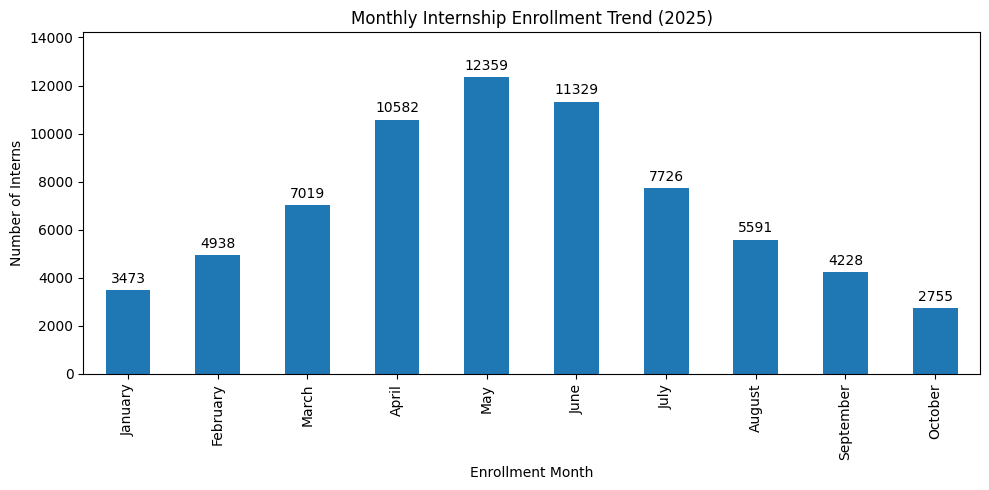

In [38]:
# Monthly Internship Enrollment Visualization

# Create the figure
plt.figure(figsize=(10, 5))

# Create the bar chart
ax = monthly_enrollment.plot(
    kind="bar"
)

# Add chart title
plt.title("Monthly Internship Enrollment Trend (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_enrollment.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/01_monthly_enrollment_trend.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship enrollment trend shows a clear seasonal pattern throughout 2025. Enrollment increased steadily from **3,473 interns in January** to a peak of **12,359 interns in May**, followed by a gradual decline through **October (2,755 interns)**. This indicates that internship registrations were concentrated during the middle months of the year rather than being evenly distributed.

#### Business Insight

The concentration of internship enrollments between **April and June** indicates the organization's peak recruitment period. To efficiently manage the increased intern intake, additional onboarding sessions, mentor availability, and training resources should be planned during these months. Conversely, the lower enrollment period from **September to October** can be utilized for program evaluation, mentor training, and preparation for the next recruitment cycle.

### Internship Completion Status Analysis

This analysis examines the overall completion status of the internship program by comparing the number of interns who successfully completed the program with those who dropped out. The findings provide insights into program completion performance and participant retention.

In [14]:
# Internship Completion Status Analysis

# Calculate the number of interns by completion status
completion_status = (
    internship_df["Status"]
    .value_counts()
)

# Display the completion status summary
completion_status

Status
Completed    59554
Dropped      10446
Name: count, dtype: int64

#### Internship Completion Status Visualization

The following visualization presents the distribution of internship completion status, highlighting the proportion of interns who successfully completed the program compared to those who dropped out.

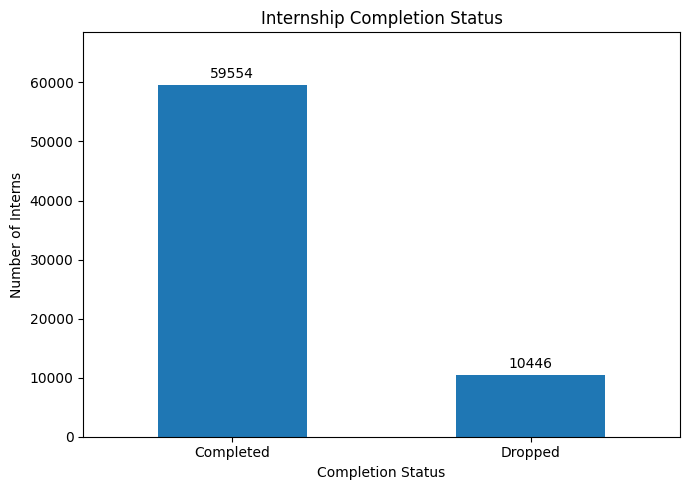

In [40]:
# Internship Completion Status Visualization

# Create the figure
plt.figure(figsize=(7, 5))

# Create the bar chart
ax = completion_status.plot(
    kind="bar"
)

# Add chart title
plt.title("Internship Completion Status")

# Add axis labels
plt.xlabel("Completion Status")
plt.ylabel("Number of Interns")

plt.ylim(0, completion_status.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
ax.bar_label(
    ax.containers[0],
    padding=3
)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/02_internship_completion_status.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The internship completion status indicates that the majority of interns successfully completed the program. Out of **70,000 interns**, **59,554** completed the internship, while **10,446** dropped out. This reflects a high completion rate, suggesting that most participants remained engaged throughout the internship program.

#### Business Insight

The high number of completed internships suggests that the program is effective in retaining participants and supporting them through successful completion. However, analyzing the reasons behind the **10,446 dropped** interns could help identify potential challenges such as workload, engagement, or mentorship gaps. Addressing these factors may further improve retention and overall program success.

### Monthly Internship Completion Status

This analysis examines the number of interns who completed or dropped the internship program across different enrollment months. It helps identify monthly variations in completion outcomes and provides insights into periods where intern retention was stronger or weaker.

In [16]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October"
]

monthly_completion = (
    internship_df
    .groupby(["Enrollment_Month", "Status"])
    .size()
    .unstack(fill_value=0)
    .reindex(month_order)
)

monthly_completion

Status,Completed,Dropped
Enrollment_Month,,
January,2951,522
February,4226,712
March,5998,1021
April,8995,1587
May,10496,1863
June,9631,1698
July,6603,1123
August,4742,849
September,3565,663


#### Monthly Internship Completion Status Visualization

This grouped bar chart illustrates the monthly distribution of completed and dropped internships based on the enrollment month. It compares the number of interns who successfully completed the internship with those who dropped out each month, making it easier to identify monthly completion patterns and evaluate intern retention throughout the internship program.

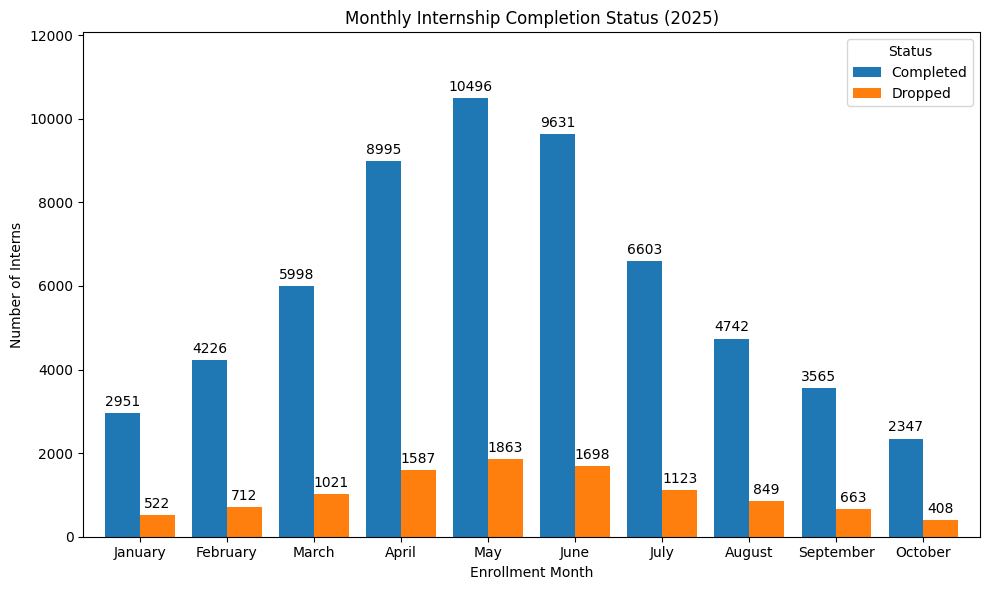

In [42]:
# Monthly Internship Completion Status Visualization



# Create the bar chart
ax = monthly_completion.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.80
)

# Add chart title
plt.title("Monthly Internship Completion Status (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_completion.max().max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/03_monthly_internship_completion_status.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship completion status shows a clear variation across enrollment months. The number of completed internships increased steadily from **2,951 in January** to a peak of **10,496 in May**, before gradually declining to **2,347 in October**. Similarly, dropped internships rose from **522 in January** to **1,863 in May** and then decreased to **408 in October**. Throughout the year, completed internships consistently remained higher than dropped internships across all enrollment months.

#### Business Insight

The monthly completion trends indicate periods of varying internship activity throughout the year. The organization should ensure sufficient mentor availability, onboarding support, and engagement initiatives during peak months, particularly from **April to June**, to effectively manage the larger number of interns. During lower-activity months, resources can be allocated to program evaluation, mentor training, and planning for future internship cycles to further strengthen intern retention and overall program performance.

### Department-wise Internship Distribution

This analysis examines the distribution of interns across different departments within the internship program. It identifies the departments that attracted the highest and lowest number of interns, providing insights into internship demand across various domains.

In [18]:
# Department-wise Internship Distribution

# Count interns in each department
department_distribution = (
    internship_df["Department"]
    .value_counts()
)

# Display summary table
department_distribution

Department
Backend Development     17958
Frontend Development    16055
Other Internships       13954
App Development         11413
Graphic Design           6983
Chatbot Development      3637
Name: count, dtype: int64

#### Department-wise Internship Distribution Visualization

This bar chart presents the number of interns enrolled in each department. It provides a clear comparison of department-wise participation, making it easier to identify the most and least popular internship departments.

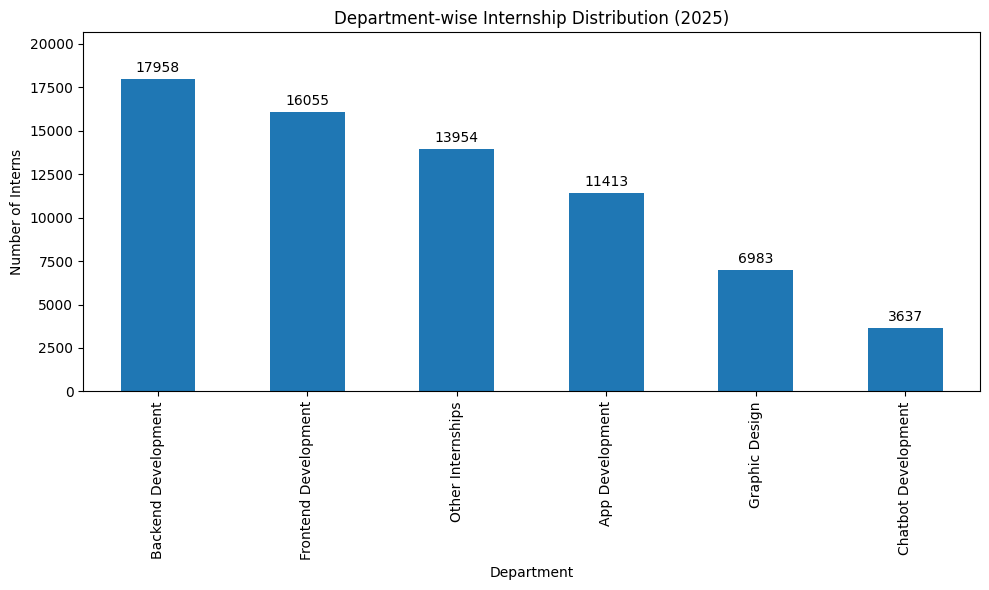

In [44]:
# Department-wise Internship Distribution Visualization

# Create the bar chart
ax = department_distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add chart title
plt.title("Department-wise Internship Distribution (2025)")

# Add axis labels
plt.xlabel("Department")
plt.ylabel("Number of Interns")

plt.ylim(0, department_distribution.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/04_department_wise_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The department-wise internship distribution shows noticeable variation across different departments. **Backend Development** recorded the highest number of interns (**17,958**), followed by **Frontend Development** (**16,055**) and **Other Internships** (**13,954**). **App Development** enrolled **11,413** interns, while **Graphic Design** (**6,983**) and **Chatbot Development** (**3,637**) had the lowest participation. This indicates that internship enrollment was concentrated in a few departments rather than being evenly distributed across all domains.

#### Business Insight

The higher enrollment in Backend and Frontend Development reflects stronger demand for software development roles within the internship program. To maintain program quality, the organization should allocate sufficient mentors, projects, and learning resources to these high-demand departments. At the same time, departments with lower participation, such as Graphic Design and Chatbot Development, can be promoted through targeted awareness campaigns and expanded project opportunities to encourage a more balanced distribution of interns.

### Monthly Department-wise Internship Distribution

This analysis examines the monthly distribution of interns across different departments throughout 2025. It highlights how internship participation varied by department over time and helps identify monthly enrollment patterns across different domains.

In [20]:
# Monthly Department-wise Internship Distribution

monthly_department_distribution = (
    internship_df
    .groupby(["Enrollment_Month", "Department"])
    .size()
    .unstack(fill_value=0)
    .reindex(month_order)
)

# Display summary table
monthly_department_distribution

Department,App Development,Backend Development,Chatbot Development,Frontend Development,Graphic Design,Other Internships
Enrollment_Month,,,,,,
January,553,909,188,752,358,713
February,791,1292,250,1120,506,979
March,1164,1800,370,1537,754,1394
April,1716,2739,543,2454,1026,2104
May,2033,3218,639,2826,1206,2437
June,1860,2823,603,2645,1132,2266
July,1247,1935,425,1824,724,1571
August,931,1482,262,1261,554,1101
September,673,1086,222,987,434,826


#### Monthly Department-wise Internship Distribution Visualization

This grouped bar chart illustrates the monthly distribution of interns across different departments. It compares department-wise internship enrollments for each month, making it easier to identify participation patterns and seasonal variations throughout the internship program.

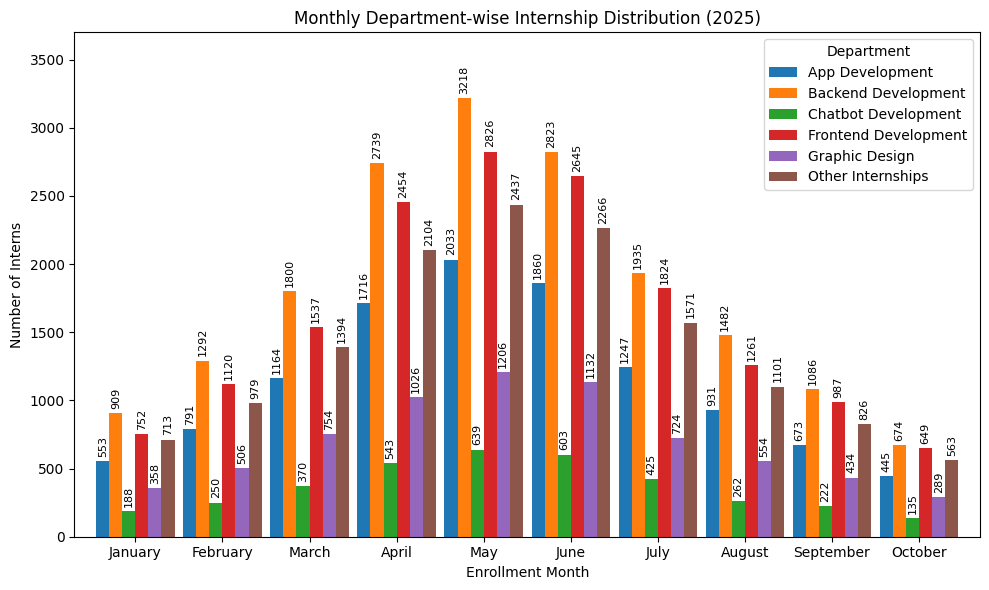

In [46]:
# Monthly Department-wise Internship Distribution Visualization

# Create the bar chart
ax = monthly_department_distribution.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.90
)

# Add chart title
plt.title("Monthly Department-wise Internship Distribution (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Number of Interns")

plt.ylim(0, monthly_department_distribution.max().max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=3,
        fontsize=8
    )
    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/05_monthly_department_wise_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly department-wise internship distribution shows that internship enrollments increased steadily from **January** and reached their highest level in **May**, followed by a gradual decline through **October**. Across all enrollment months, **Backend Development** consistently recorded the highest number of interns, followed by **Frontend Development** and **Other Internships**. In contrast, **Graphic Design** and **App Development** maintained comparatively lower enrollment counts throughout the internship period.

#### Business Insight

The consistently higher enrollments in **Backend Development** and **Frontend Development** indicate strong and sustained demand for software development-related internship tracks. During peak enrollment months, particularly **April** and **May**, the organization should allocate additional mentors, technical resources, and project opportunities to accommodate increased participation. Furthermore, targeted promotional initiatives and specialized internship projects for departments with lower enrollments, such as **Graphic Design** and **App Development**, may help improve participation and create a more balanced internship portfolio.

### Internship Track Distribution

This analysis examines the distribution of interns across different internship tracks. It identifies the most and least popular tracks, providing insights into intern preferences and the organization's demand across various career pathways.

In [22]:
# Internship Track Distribution

track_distribution = (
    internship_df["Internship_Track"]
    .value_counts()
    .rename("Number of Interns")
)

# Display summary table
track_distribution

Internship_Track
PHP                 6347
Node.js             4416
React               4397
Flutter             4395
MERN Stack          3622
HTML CSS JS         3573
React Native        3366
Data Science        3333
Data Analytics      2927
WordPress           2835
Photoshop           2709
Android             2486
Next.js             2258
Illustrator         1925
Cloud Computing     1871
MEAN Stack          1808
Figma               1795
Web 3.0             1765
Machine Learning    1681
Cyber Security      1651
Social Media        1393
Generative AI       1378
Angular             1340
Swift               1166
Video Editing       1098
Django              1032
Dialogflow           800
RASA                 737
.NET Core            620
Autodesk Maya        554
Alexa Skill          378
Salesforce CRM       344
Name: Number of Interns, dtype: int64

#### Internship Track Distribution Visualization

This bar chart illustrates the number of interns enrolled in each internship track. It provides a comparison of track-wise participation, highlighting the most and least preferred internship tracks within the program.

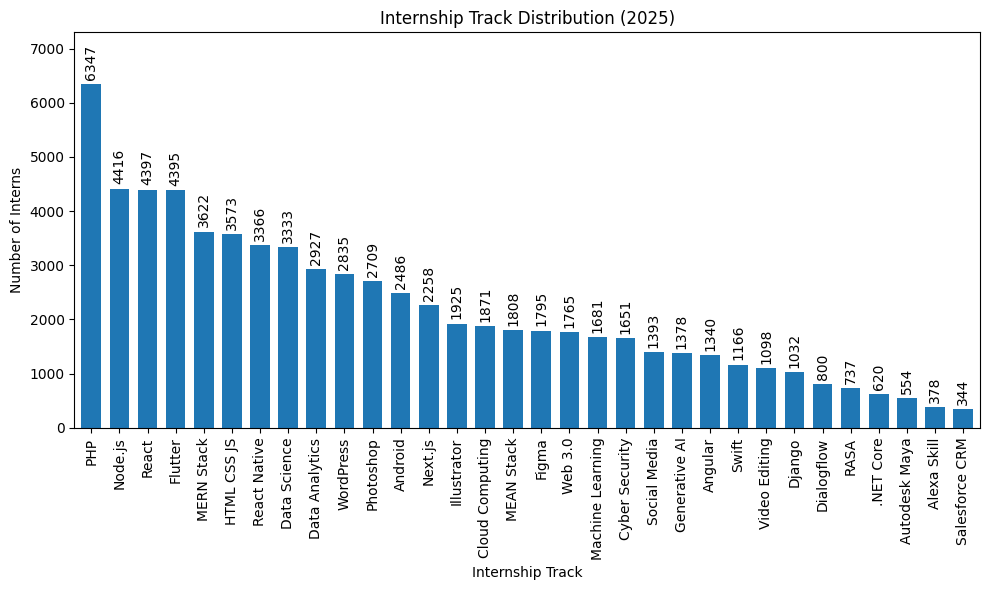

In [48]:
# Internship Track Distribution Visualization

# Create the bar chart
ax = track_distribution.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.70
)

# Add chart title
plt.title("Internship Track Distribution (2025)")

# Add axis labels
plt.xlabel("Internship Track")
plt.ylabel("Number of Interns")

plt.ylim(0, track_distribution.max() * 1.15)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=3
    )

    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/06_internship_track_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The internship track distribution reveals that **PHP** recorded the highest number of interns, followed by **Node.js**, **React**, and **Flutter**. Web development-related tracks collectively attracted the largest share of internship enrollments, indicating strong interest in full-stack and frontend technologies. In contrast, specialized tracks such as **.NET Core**, **Autodesk Maya**, **Alexa Skill** and **Salesforce CRM** received comparatively lower enrollments, reflecting relatively limited participation.

#### Business Insight

The high demand for **PHP**, **Node.js**, **React**, and other web development technologies suggests that these tracks should remain a primary focus for mentor allocation, project availability, and training resources. At the same time, lower-enrollment tracks such as **Autodesk Maya**, **Alexa Skill** and **Salesforce CRM** may benefit from targeted awareness campaigns, updated learning content, and industry-relevant projects to improve participation and diversify the internship portfolio.

### Monthly Internship Track Distribution

This Table presents the monthly distribution of internship enrollments across different internship tracks. It compares participation trends for each internship track across all enrollment months, helping identify seasonal enrollment patterns, peak participation periods, and changes in demand throughout the internship program.

In [24]:
# Monthly Internship Track Distribution

monthly_track_distribution = (
    internship_df
        .groupby(["Enrollment_Month", "Internship_Track"])
        .size()
        .unstack(fill_value=0)
        .reindex(month_order)
)

# Sort tracks by total enrollments (highest to lowest)
monthly_track_distribution = monthly_track_distribution[
    monthly_track_distribution.sum().sort_values(ascending=False).index
]

monthly_track_distribution.T

Enrollment_Month,January,February,March,April,May,June,July,August,September,October
Internship_Track,,,,,,,,,,
PHP,317,483,643,932,1168,984,690,495,400,235
Node.js,228,315,462,689,775,704,505,344,247,147
React,197,308,417,652,781,742,487,349,277,187
Flutter,203,294,495,645,795,714,454,373,256,166
MERN Stack,183,237,373,558,609,587,382,343,211,139
HTML CSS JS,176,270,331,564,618,566,419,283,206,140
React Native,175,232,335,511,600,540,385,261,200,127
Data Science,177,238,293,504,595,561,367,271,195,132
Data Analytics,139,191,300,461,495,495,322,244,156,124


#### Monthly Internship Track Distribution Visualization

This heatmap illustrates the monthly distribution of internship enrollments across different internship tracks. Darker color intensity represents higher enrollment counts, making it easier to identify peak participation periods and compare enrollment trends across internship tracks throughout 2025.

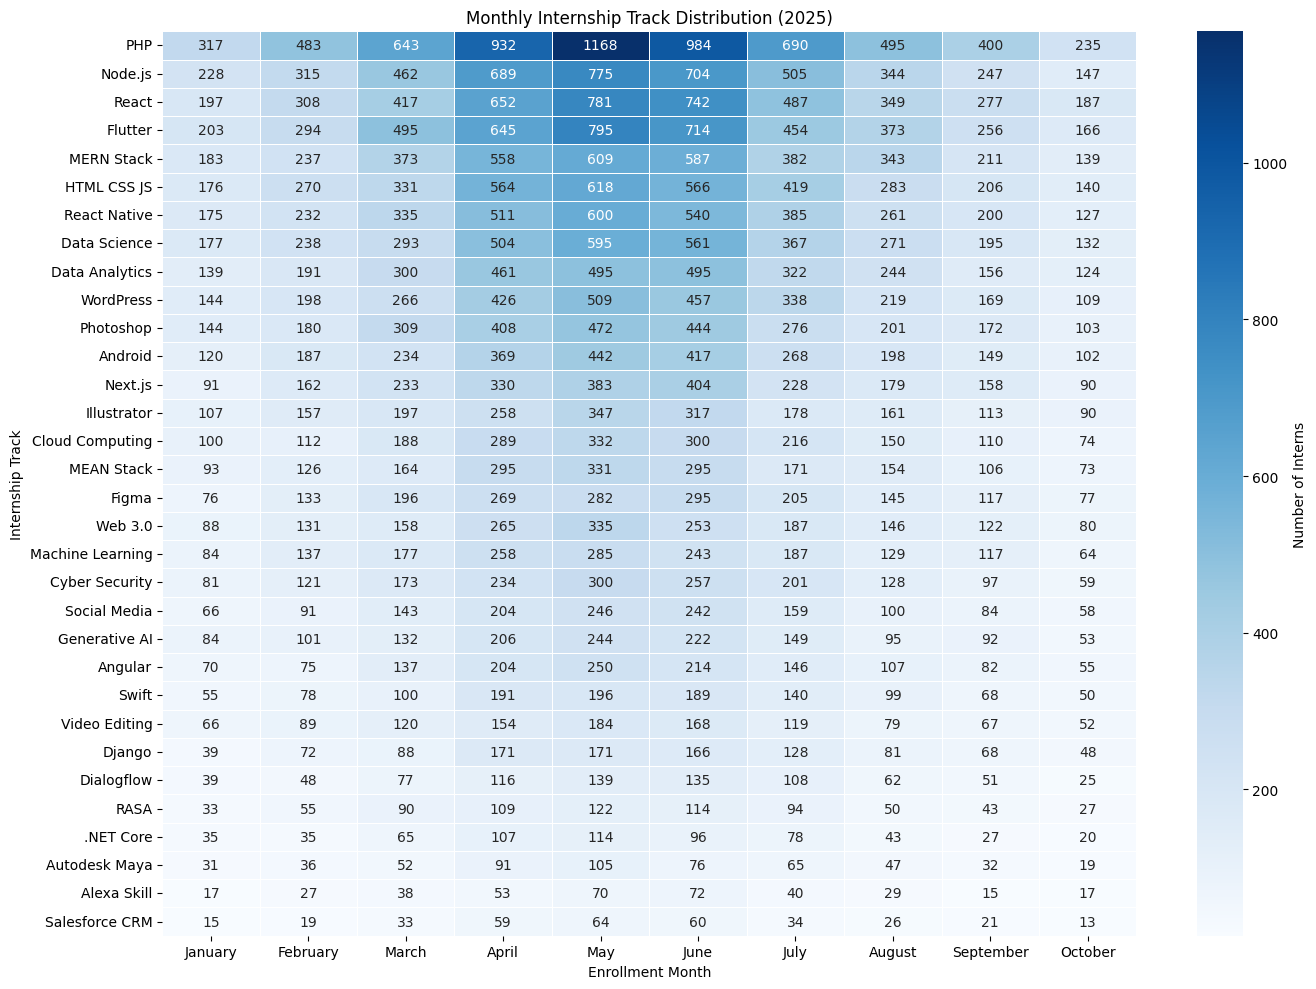

In [50]:
# Monthly Internship Track Distribution Visualization

# Create the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    monthly_track_distribution.T,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of Interns"}
)

# Add chart title
plt.title("Monthly Internship Track Distribution (2025)")

# Add axis labels
plt.xlabel("Enrollment Month")
plt.ylabel("Internship Track")

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/07_monthly_internship_track_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The monthly internship track distribution heatmap shows that internship enrollments increased steadily from **January** and peaked during **May**, followed by a gradual decline through **October** across nearly all internship tracks. **PHP**, **Node.js**, **React**, and **Flutter** consistently recorded the highest enrollment counts throughout the internship period, while tracks such as **.NET Core**, **Autodesk Maya**, **Alexa Skill** and **Salesforce CRM** maintained comparatively lower participation. Overall, the monthly enrollment pattern remained consistent across all internship tracks.

#### Business Insight

The consistently high demand for **PHP**, **Node.js**, **React**, and **Flutter** indicates that these internship tracks should continue to receive priority in mentor allocation, technical resources, and project opportunities, especially during the peak enrollment months of **April**, **May**, and **June**. Additionally, lower-enrollment tracks such as **Autodesk Maya**, **Alexa Skill** and **Salesforce CRM** may benefit from targeted promotional campaigns, updated learning content, and industry-focused projects to increase participation and create a more balanced internship portfolio.

### Gender Distribution

This Table illustrates the distribution of interns by gender. It provides an overview of gender representation within the internship program, helping identify participation patterns and assess diversity across the enrolled interns.

In [26]:
# Gender Distribution

gender_distribution = (
    internship_df["Gender"]
    .value_counts()
)

gender_distribution

Gender
Male      51266
Female    18734
Name: count, dtype: int64

#### Gender Distribution Visualization

This bar chart illustrates the distribution of interns by gender. It compares the number of male and female interns, providing insights into gender representation within the internship program.

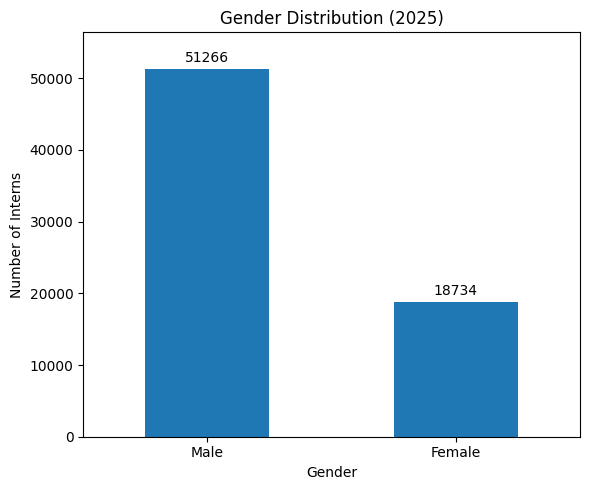

In [52]:
# Gender Distribution Visualization

# Create the bar chart
ax = gender_distribution.plot(
    kind="bar",
    figsize=(6, 5)
)

# Add chart title
plt.title("Gender Distribution (2025)")

# Add axis labels
plt.xlabel("Gender")
plt.ylabel("Number of Interns")

plt.ylim(0, gender_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/08_gender_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The gender distribution shows that **Male** interns (51,266) significantly outnumber **Female** interns (18,734). This indicates that the internship program attracted substantially higher participation from male candidates during 2025, while female representation remained comparatively lower.


#### Business Insight

The higher participation of male interns suggests an opportunity to improve gender diversity within the internship program. The organization can encourage greater female participation by conducting targeted outreach campaigns, collaborating with women's universities and colleges, and promoting inclusive internship opportunities. Maintaining equal access to mentorship, training, and project opportunities will further support a more balanced and diverse internship cohort in future recruitment cycles.

### Age Distribution

This Table illustrates the distribution of interns across different age groups. It provides insights into the age profile of participants, helping identify the most common age ranges within the internship program.

In [28]:
# Age Distribution

age_distribution = (
    internship_df["Age"]
    .value_counts()
    .sort_index()
)

age_distribution

Age
17    1425
18    2029
19    8657
20    8802
21    7365
22    7240
23    7734
24    7615
25    7630
26    7757
27     816
28     747
29     740
30     697
31     365
32     381
Name: count, dtype: int64

#### Age Distribution Visualization

This bar chart illustrates the distribution of interns across different ages. It compares the number of interns in each age group, providing insights into the overall age profile of participants in the internship program.

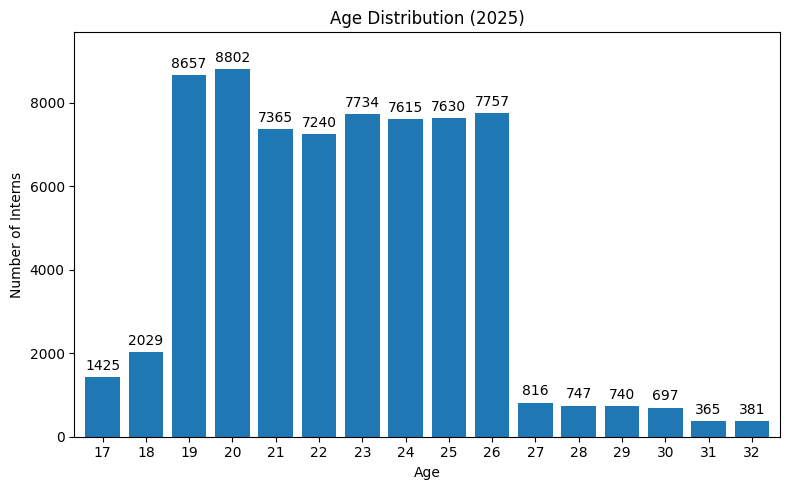

In [54]:
# Age Distribution Visualization

# Create the bar chart
ax = age_distribution.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.80
)

# Add chart title
plt.title("Age Distribution (2025)")

# Add axis labels
plt.xlabel("Age")
plt.ylabel("Number of Interns")

plt.ylim(0, age_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/09_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The age distribution shows that the majority of interns fall between **19 and 26 years** of age, with **19** and **20** years recording the highest number of enrollments. Participation declines noticeably for ages **17**, **18**, and **27–32**, indicating that relatively fewer interns belong to these age groups. Overall, the internship program primarily attracts young adults in the typical university-age range.

#### Business Insight

The concentration of interns between **19 and 26 years** suggests that the internship program primarily serves undergraduate and early-career students. Organizations should continue designing training content, mentorship programs, and project assignments that align with the learning needs of this age group. Additionally, targeted outreach initiatives for younger and older age groups may help broaden participation and create a more diverse internship community.

### Education Distribution

This Table illustrates the distribution of interns based on their educational qualification. It provides an overview of the academic backgrounds of participants, helping identify the education levels most represented in the internship program.

In [30]:
# Education Distribution

education_distribution = (
    internship_df["Education"]
    .value_counts()
)

education_distribution

Education
BS Computer Science                      10365
BS Information Technology                 8930
BS Software Engineering                   8241
BS Artificial Intelligence                6243
BS Data Science                           6182
BS Data Analytics                         5279
BS Computer Engineering                   4218
BS Cyber Security                         4190
MS Computer Science                       3243
ICS                                       2644
MCS                                       2551
FSC (Pre-Engineering)                     2126
DAE (Computer Information Technology)     2119
BBA                                       1023
DAE (Electrical Technology)                553
MBA                                        532
FSC (Pre-Medical)                          523
ICOM                                       522
DAE (Mechanical Technology)                516
Name: count, dtype: int64

#### Education Distribution Visualization

This bar chart illustrates the distribution of interns across different educational qualifications. It compares the number of interns in each education category, providing insights into the academic profile of participants in the internship program.

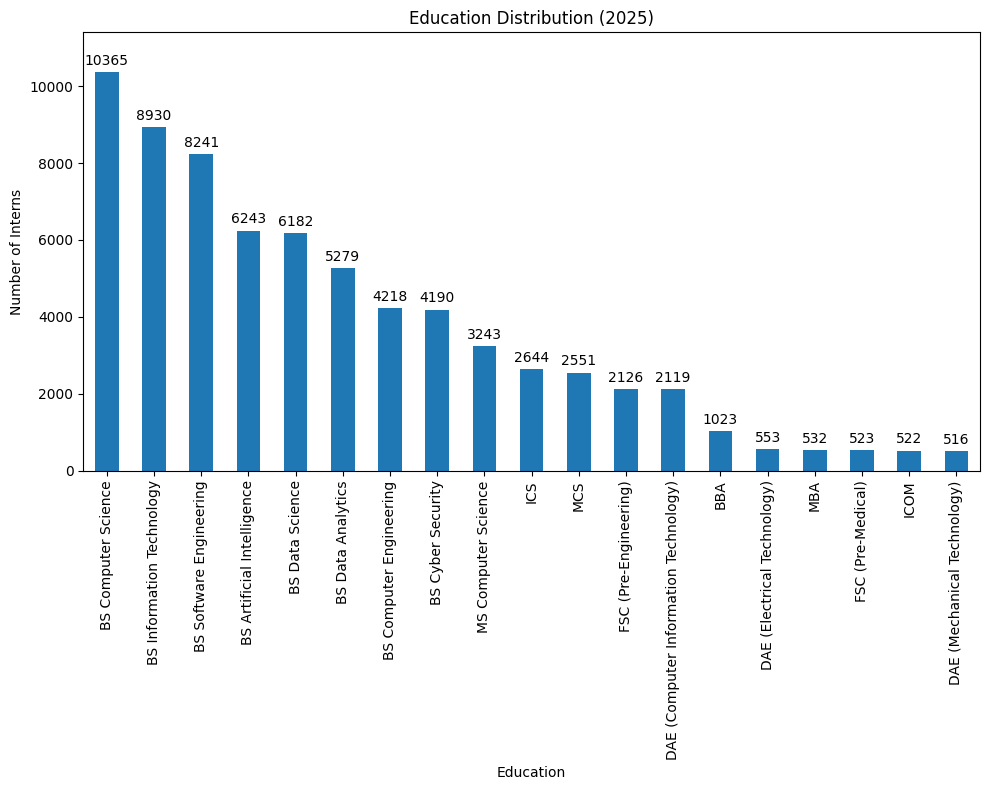

In [56]:
# Education Distribution Visualization

# Create the bar chart
ax = education_distribution.plot(
    kind="bar",
    figsize=(10, 8)
)

# Add chart title
plt.title("Education Distribution (2025)")

# Add axis labels
plt.xlabel("Education")
plt.ylabel("Number of Interns")

plt.ylim(0, education_distribution.max() * 1.10)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/10_education_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The education distribution indicates that **BS Computer Science** recorded the highest number of internship enrollments, followed by **BS Information Technology** and **BS Software Engineering**. Other computing-related disciplines, including **BS Artificial Intelligence**, **BS Data Science**, and **BS Data Analytics**, also contributed a substantial number of interns. In contrast, non-computing and diploma-level qualifications, such as **DAE**, **FSC**, **ICOM**, and **MBA**, accounted for comparatively lower participation.

#### Business Insight

The strong representation of **Computer Science**, **Information Technology**, and **Software Engineering** students indicates that the internship program primarily attracts participants from computing-related disciplines. Organizations should continue offering technical projects, mentorship, and learning opportunities tailored to these academic backgrounds. At the same time, targeted outreach and specialized internship pathways for students from non-computing disciplines may help broaden participation and promote a more diverse internship portfolio.

### Institute Distribution

This Table illustrates the distribution of interns across different educational institutes. It provides an overview of institutional representation within the internship program, helping identify the institutes that contributed the highest number of interns during 2025.

In [32]:
# Institute Distribution

institute_distribution = (
    internship_df["Institute"]
    .value_counts()
)

institute_distribution

Institute
University of Engineering and Technology (UET)           6095
University of Education                                  5962
Government College University (GCU)                      5605
University of the Punjab                                 5113
University of Central Punjab                             5072
FAST National University                                 5029
Virtual University of Pakistan                           4990
COMSATS University Islamabad                             4203
National University of Sciences and Technology (NUST)    3590
Superior University                                      3084
University of Management and Technology (UMT)            2592
Air University                                           2570
Riphah International University                          2542
Bahria University                                        2507
Iqra University                                          2043
Punjab Group of Colleges                                 111

#### Institute Distribution Visualization

This bar chart illustrates the distribution of interns across different educational institutes. It compares the number of interns contributed by each institute, providing insights into institutional participation in the internship program.

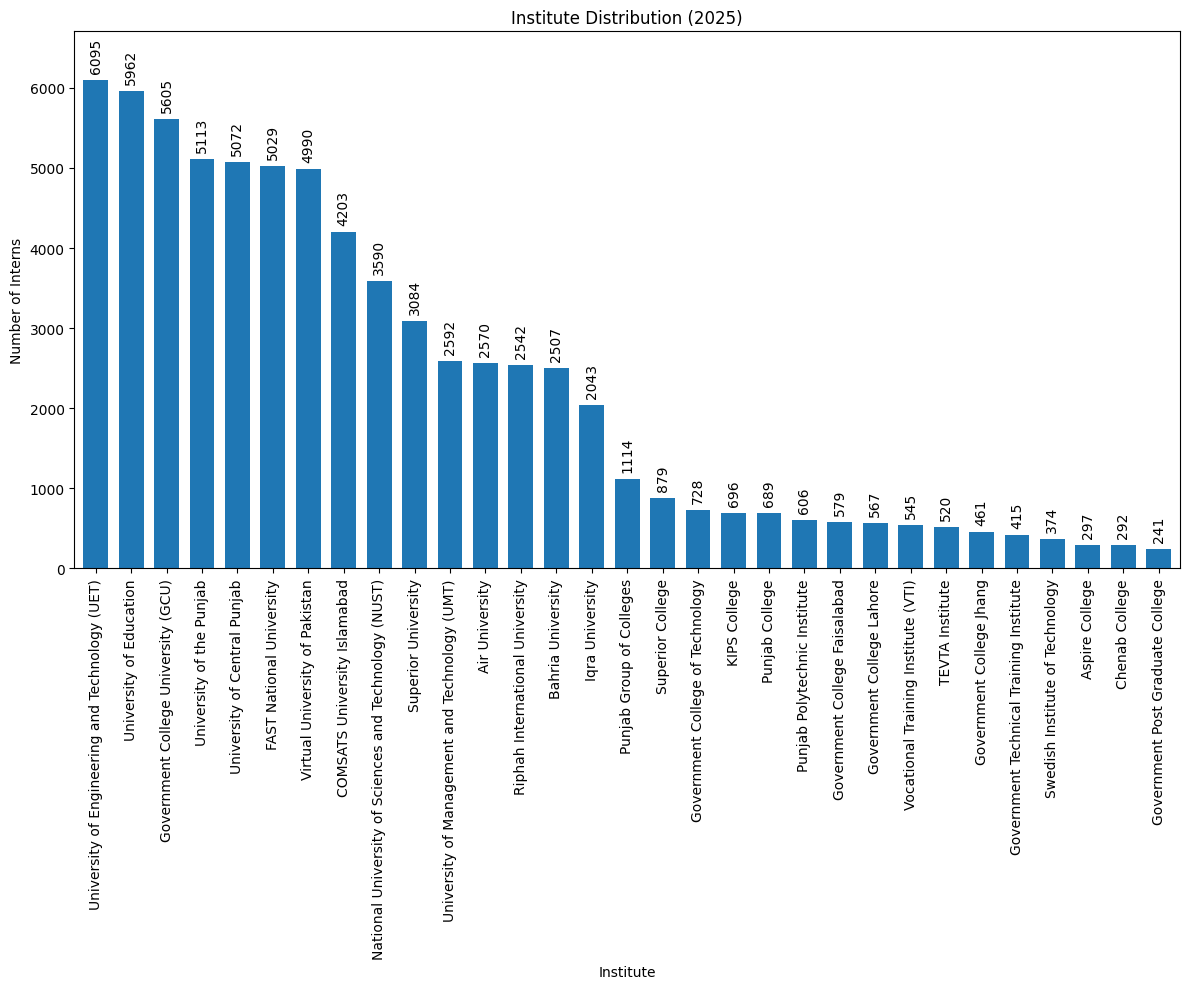

In [58]:
# Institute Distribution Visualization

# Create the bar chart
ax = institute_distribution.plot(
    kind="bar",
    figsize=(12, 10),
    width=0.7
)

# Add chart title
plt.title("Institute Distribution (2025)")

# Add axis labels
plt.xlabel("Institute")
plt.ylabel("Number of Interns")

plt.ylim(0, institute_distribution.max() * 1.10)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=5
    )

    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/11_institute_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The institute distribution shows that internship participation is primarily concentrated among universities offering computing-related programs. **The University of Engineering and Technology (UET)** recorded the highest number of interns, closely followed by the **University of Education**, **Government College University (GCU)**, **University of the Punjab**, **University of Central Punjab** and **FAST National University**. In contrast, colleges and vocational institutes contributed comparatively fewer interns, indicating lower participation from these educational institutions.

#### Business Insight

The strong participation from major universities demonstrates the effectiveness of the internship program in attracting students from higher education institutions. To further expand its reach, the organization should strengthen partnerships with universities while also increasing awareness and collaboration with colleges, vocational institutes, and technical education providers. This approach can improve institutional diversity and broaden access to internship opportunities.

### City Distribution

This analysis illustrates the distribution of interns across different cities. It provides an overview of the geographical representation of participants, helping identify the cities that contributed the highest number of interns to the internship program during 2025.

In [79]:
# City Distribution

city_distribution = (
    internship_df["City"]
        .value_counts()
)

city_distribution

City
Lahore             7081
Karachi            5870
Faisalabad         4554
Islamabad          3748
Rawalpindi         3623
Multan             3210
Gujranwala         2544
Peshawar           2537
Sialkot            2264
Sargodha           1964
Hyderabad          1950
Sahiwal            1631
Bahawalpur         1611
Sheikhupura        1582
Gujrat             1576
Kasur              1323
Okara              1317
Rahim Yar Khan     1314
Quetta             1282
Jhang              1278
Abbottabad         1275
Mardan             1216
Khushab            1003
Vehari              996
Nawabshah           985
Mingora             984
Muzaffarabad        965
Wah Cantt           953
Nowshera            951
Sukkur              947
Larkana             945
Pakpattan           945
Dera Ghazi Khan     907
Chiniot             891
Gwadar              715
Bannu               622
Kohat               619
Jacobabad           612
Turbat              611
Mirpur Khas         599
Name: count, dtype: int64

#### City Distribution Visualization

This bar chart illustrates the distribution of interns across different cities. It compares the number of interns contributed by each city, providing insights into the geographical reach of the internship program.

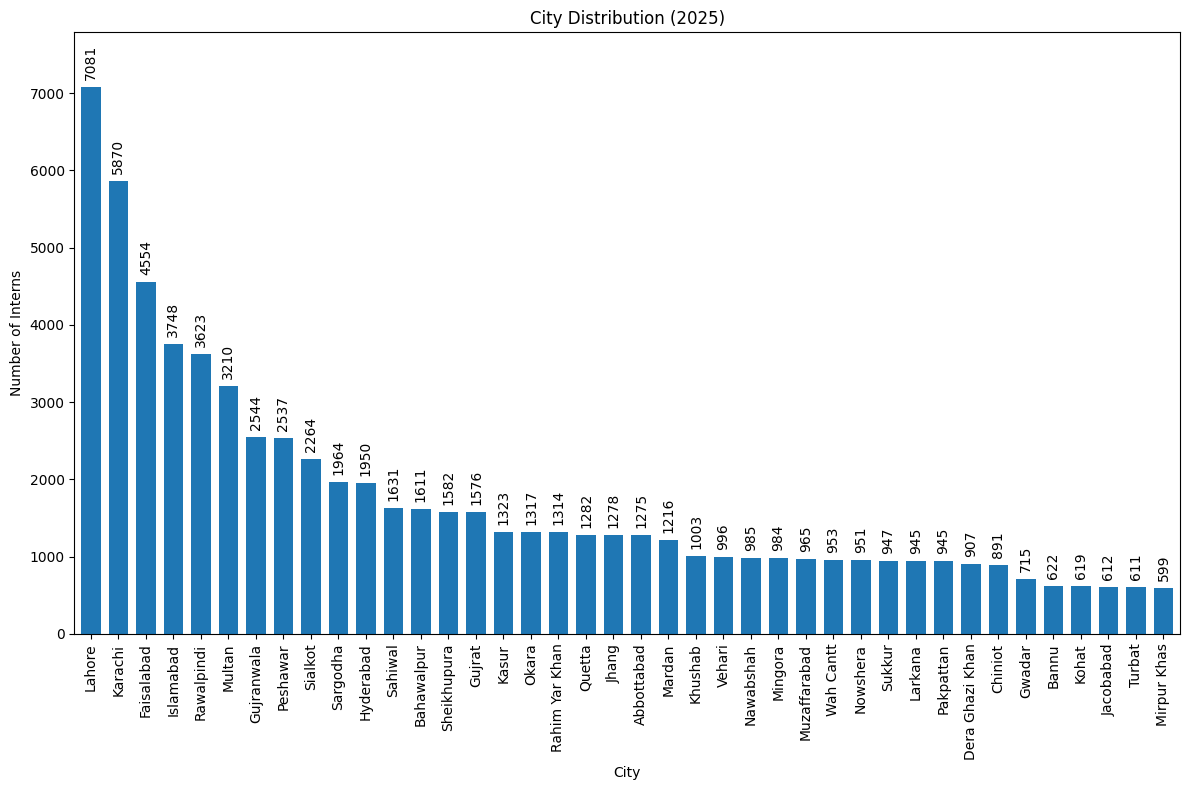

In [64]:
# City Distribution Visualization

# Create the bar chart
ax = city_distribution.plot(
    kind="bar",
    figsize=(12, 8),
    width=0.7
)

# Add chart title
plt.title("City Distribution (2025)")

# Add axis labels
plt.xlabel("City")
plt.ylabel("Number of Interns")

plt.ylim(0, city_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=90)

# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=5
    )

    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/12_city_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The city distribution indicates that **Lahore** recorded the highest number of internship enrollments, followed by **Karachi**, **Faisalabad**, **Islamabad**, and **Rawalpindi**. Participation gradually decreases across the remaining cities, with smaller cities such as **Mirpur Khas**, **Turbat**, **Jacobabad**, and **Bannu** contributing comparatively fewer interns. Overall, the internship program attracted participants from a wide geographical range across Pakistan, with stronger representation from major metropolitan and educational hubs.

#### Business Insight

The high participation from major cities such as **Lahore**, **Karachi**, and **Faisalabad** indicates strong awareness and accessibility of the internship program in these regions. To expand its geographical reach, the organization should strengthen promotional campaigns, institutional partnerships, and outreach initiatives in underrepresented cities. Increasing engagement in smaller cities can help create a more geographically diverse internship cohort while improving equal access to internship opportunities nationwide.

### Status Distribution by Gender

This analysis illustrates the internship completion status across different gender groups. It compares the number of completed and dropped interns for each gender, providing insights into gender-wise internship outcomes during 2025.

In [66]:
# Status Distribution by Gender

gender_status_distribution = (
    internship_df.groupby(["Gender", "Status"])
        .size()
        .unstack(fill_value=0)
)

gender_status_distribution

Status,Completed,Dropped
Gender,,
Female,15976,2758
Male,43578,7688


#### Status Distribution by Gender Visualization

This grouped bar chart compares the number of completed and dropped interns across different gender groups. It helps evaluate internship outcomes and identify participation patterns by gender.

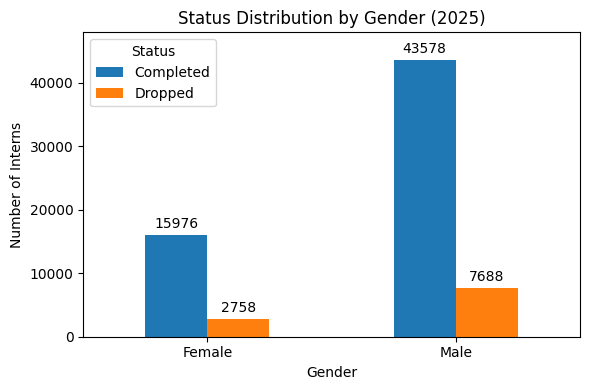

In [71]:
# Status Distribution by Gender Visualization

# Create the bar chart
ax = gender_status_distribution.plot(
    kind="bar",
    figsize=(6, 4)
)

# Add chart title
plt.title("Status Distribution by Gender (2025)")

# Add axis labels
plt.xlabel("Gender")
plt.ylabel("Number of Interns")

plt.ylim(0, gender_status_distribution.max().max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/13_status_distribution_by_gender.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The status distribution by gender shows that the majority of interns from both gender groups successfully completed the internship program. **Male** interns recorded a higher number of both completed (43,578) and dropped (7,688) cases compared to **Female** interns, primarily because male participation was substantially higher. Overall, the completion rate remained consistently high across both genders.

#### Business Insight

The consistently high completion counts for both male and female interns indicate effective engagement and successful program delivery across gender groups. While maintaining the current completion performance, the organization should focus on increasing female participation through targeted outreach and inclusive recruitment strategies, enabling a more balanced internship cohort without compromising completion outcomes.

### Status Distribution by Department

This analysis illustrates the internship completion status across different departments. It compares the number of completed and dropped interns in each department, helping evaluate department-wise internship outcomes during 2025.

In [80]:
# Status Distribution by Department

department_status_distribution = (
    internship_df.groupby(["Department", "Status"])
        .size()
        .unstack(fill_value=0)
        .sort_values(by="Completed", ascending=False)
    
)

department_status_distribution

Status,Completed,Dropped
Department,,
Backend Development,15319,2639
Frontend Development,13574,2481
Other Internships,11952,2002
App Development,9681,1732
Graphic Design,5933,1050
Chatbot Development,3095,542


#### Status Distribution by Department Visualization

This grouped bar chart compares the number of completed and dropped interns across different departments. It provides insights into department-wise internship completion patterns and participant retention.

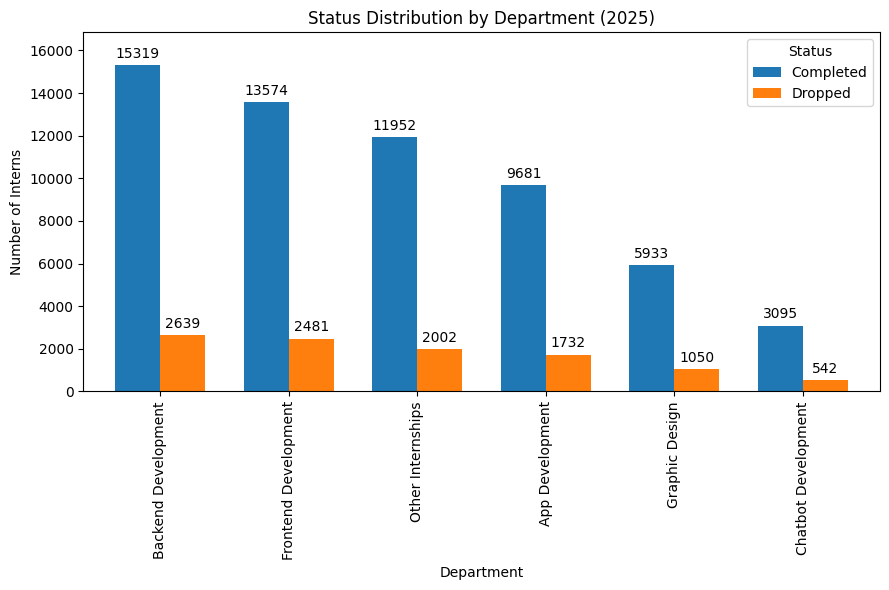

In [83]:
# Status Distribution by Department Visualization

# Create the bar chart
ax = department_status_distribution.plot(
    kind="bar",
    figsize=(9, 6),
    width=0.7
)

# Add chart title
plt.title("Status Distribution by Department (2025)")

# Add axis labels
plt.xlabel("Department")
plt.ylabel("Number of Interns")

plt.ylim(0, department_status_distribution.max().max() * 1.10)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/14_status_distribution_by_department.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The status distribution by department shows that **Backend Development** recorded the highest number of completed interns, followed by **Frontend Development** and **Other Internships**. Across all departments, the number of completed interns was substantially higher than the number of dropped interns, indicating consistently strong completion performance. **Chatbot Development** recorded the lowest number of both completed and dropped interns, reflecting its comparatively smaller enrollment size.

#### Business Insight

The consistently high completion counts across all departments indicate effective mentor support and successful internship delivery. Since **Backend Development** and **Frontend Development** attract the largest number of participants, these departments should continue receiving priority in mentor allocation, technical resources, and project availability. Meanwhile, departments with lower participation, such as **Chatbot Development** and **Graphic Design**, can be strengthened through targeted promotion and specialized learning opportunities to increase enrollments while maintaining high completion rates.

### Status Distribution by Internship Track

This analysis illustrates the internship completion status across different internship tracks. It compares the number of completed and dropped interns in each internship track, helping evaluate track-wise completion patterns and participant retention during 2025.

In [78]:
# Status Distribution by Internship Track

track_status_distribution = (
    internship_df.groupby(["Internship_Track", "Status"])
      .size()
      .unstack(fill_value=0)
      .sort_values(by="Completed", ascending=False)
)

track_status_distribution

Status,Completed,Dropped
Internship_Track,,
PHP,5406,941
Node.js,3777,639
React,3742,655
Flutter,3718,677
MERN Stack,3108,514
HTML CSS JS,3010,563
React Native,2874,492
Data Science,2869,464
Data Analytics,2511,416


#### Status Distribution by Internship Track Visualization

This grouped bar chart compares the number of completed and dropped interns across different internship tracks. It helps identify internship tracks with the highest completion levels and provides insights into participant retention across various technical domains.

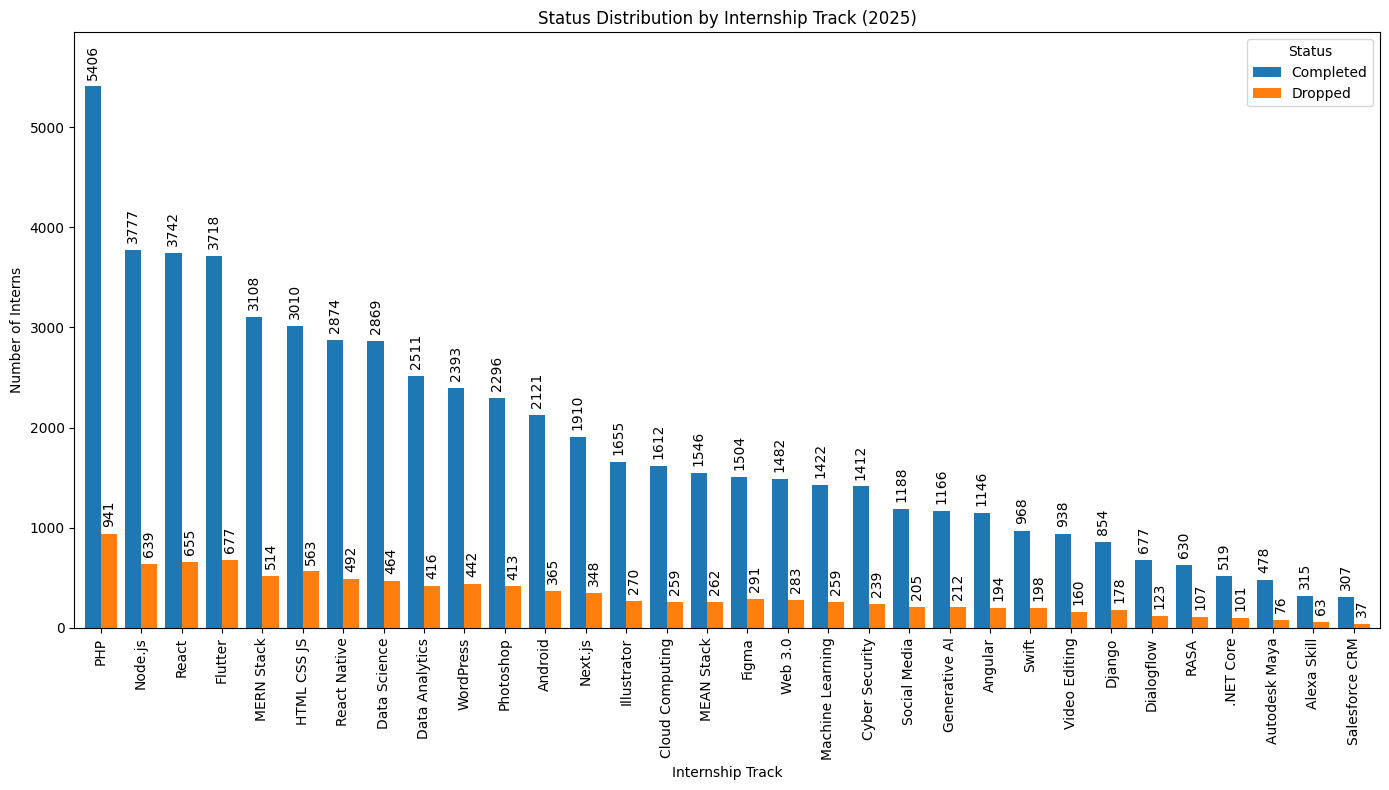

In [92]:
# Status Distribution by Internship Track Visualization

# Create the bar chart
ax = track_status_distribution.plot(
    kind="bar",
    figsize=(14, 8),
    width=0.80
)

# Add chart title
plt.title("Status Distribution by Internship Track (2025)")

# Add axis labels
plt.xlabel("Internship Track")
plt.ylabel("Number of Interns")

plt.ylim(0, track_status_distribution.max().max() * 1.10)


# Display data labels
for container in ax.containers:
    labels = ax.bar_label(
        container,
        padding=5
    )

    for label in labels:
        label.set_rotation(90)

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/15_status_distribution_by_internship_track.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The status distribution by internship track shows that **PHP** recorded the highest number of completed interns, followed by **Node.js**, **React**, **Flutter**, and **MERN Stack**. Across all internship tracks, the number of completed interns substantially exceeded the number of dropped interns, indicating consistently strong completion performance. Specialized tracks such as **Salesforce CRM**, **Alexa Skill**, and **Autodesk Maya** recorded comparatively lower numbers of both completed and dropped interns, reflecting their relatively smaller enrollment sizes.

#### Business Insight

The consistently high completion counts in **PHP**, **Node.js**, **React**, and **Flutter** indicate strong participant interest and successful program delivery in these high-demand technical tracks. The organization should continue prioritizing mentor allocation, technical resources, and project opportunities for these tracks while promoting specialized tracks such as **Salesforce CRM**, **Alexa Skill**, and **Autodesk Maya** through targeted awareness campaigns and industry-focused projects to improve participation without compromising completion rates.

### Tasks Submitted Distribution

This analysis illustrates the distribution of tasks submitted by interns during the internship program. It provides an overview of task completion patterns, helping evaluate intern participation and submission behavior throughout 2025.

In [94]:
# Tasks Submitted Distribution

tasks_distribution = (
    internship_df["Tasks_Submitted"]
    .value_counts()
    .sort_index()
)

tasks_distribution

Tasks_Submitted
0     2257
1     2183
2     1744
3     1559
4     1448
5     1255
6    11906
7    20834
8    26814
Name: count, dtype: int64

#### Tasks Submitted Distribution Visualization

This bar chart illustrates the distribution of interns by the number of tasks submitted. It highlights submission patterns and helps assess overall engagement and task completion throughout the internship program.

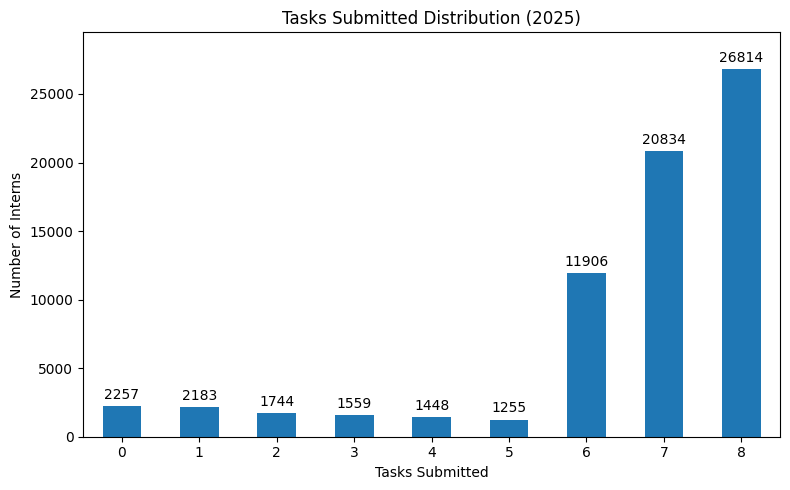

In [99]:
# Tasks Submitted Distribution Visualization

# Create the bar chart
ax = tasks_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title
plt.title("Tasks Submitted Distribution (2025)")

# Add axis labels
plt.xlabel("Tasks Submitted")
plt.ylabel("Number of Interns")

plt.ylim(0, tasks_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/16_tasks_submitted_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The tasks submitted distribution shows that the majority of interns submitted **6 to 8 tasks**, with **8 tasks** being the most common submission count, followed by **7** and **6** tasks. In contrast, relatively few interns submitted **0 to 5 tasks**, indicating lower participation among those who did not complete the internship requirements. Overall, the distribution reflects a strong tendency toward completing the required internship tasks.

#### Business Insight

The high number of interns submitting **6 to 8 tasks** indicates strong participant engagement and successful completion of internship requirements. To further improve completion rates, the organization should identify interns with low task submissions (0–5 tasks) at an early stage and provide timely mentor support, progress monitoring, and motivational interventions to reduce dropout risk and increase successful task completion.

### Weeks Completed Distribution

This analysis illustrates the distribution of interns based on the number of weeks completed during the internship program. It provides insights into internship progress, participant retention, and overall completion patterns throughout 2025.

In [101]:
# Weeks Completed Distribution

weeks_completed_distribution = (
    internship_df["Weeks_Completed"]
    .value_counts()
    .sort_index()
)

weeks_completed_distribution

Weeks_Completed
1      706
2      672
3      683
4     1390
5     1428
6     2082
7     3485
8    59554
Name: count, dtype: int64

#### Weeks Completed Distribution Visualization

This bar chart illustrates the distribution of interns based on the number of weeks completed. It highlights internship progression and helps evaluate participant retention throughout the internship program.

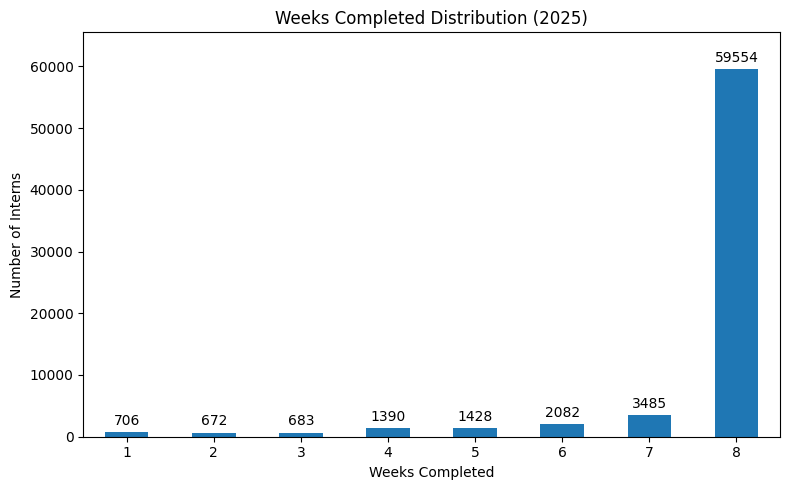

In [105]:
# Weeks Completed Distribution Visualization

# Create the bar chart
ax = weeks_completed_distribution.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title
plt.title("Weeks Completed Distribution (2025)")

# Add axis labels
plt.xlabel("Weeks Completed")
plt.ylabel("Number of Interns")

plt.ylim(0, weeks_completed_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/17_weeks_completed_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The weeks completed distribution shows that the vast majority of interns completed the full **8-week** internship, making it the most frequently recorded duration by a substantial margin. In comparison, relatively few interns completed **1 to 7 weeks**, with the number of participants gradually increasing from week 4 onwards. Overall, the distribution indicates a high internship completion rate and strong participant retention throughout the program.

#### Business Insight

The high number of interns completing all **8 weeks** reflects effective program engagement, mentor support, and participant commitment. To further improve retention, the organization should closely monitor interns during the early and middle stages of the internship (Weeks **1–7**) and provide timely guidance, mentorship, and progress tracking to help more participants successfully complete the full internship duration.

### Mentor Interactions Distribution

This analysis illustrates the distribution of mentor interactions throughout the internship program. It provides insights into mentor engagement levels and the frequency of communication between mentors and interns during 2025.

In [106]:
# Mentor Interactions Distribution

mentor_interactions_distribution = (
    internship_df["Mentor_Interactions"]
    .value_counts()
    .sort_index()
)

mentor_interactions_distribution

Mentor_Interactions
2       230
3       433
4       409
5       317
6       345
7       538
8       528
9       675
10      672
11      770
12      758
13     1141
14     1145
15    10889
16    10578
17    10642
18     9874
19    10077
20     9979
Name: count, dtype: int64

#### Mentor Interactions Distribution Visualization

This bar chart illustrates the distribution of mentor interactions throughout the internship program. It highlights communication frequency between mentors and interns, providing insights into mentoring engagement and participant support.

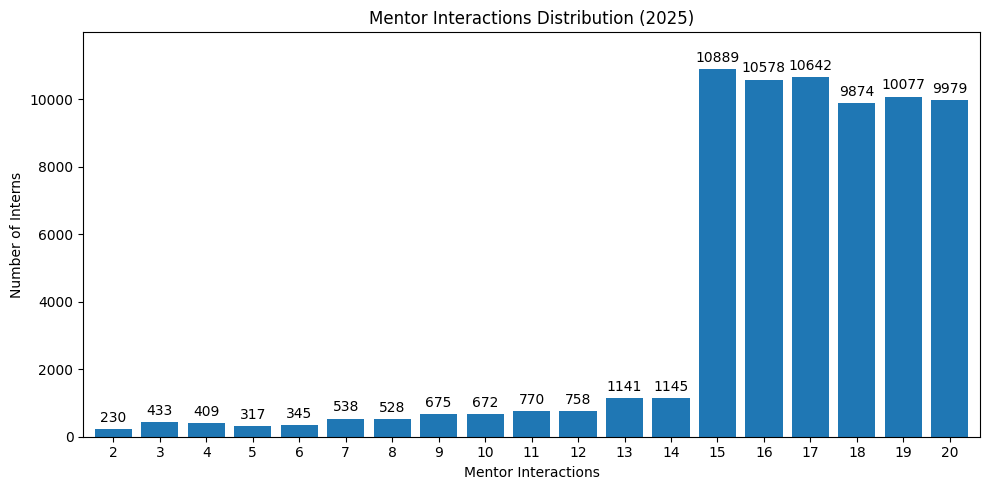

In [111]:
# Mentor Interactions Distribution Visualization

# Create the bar chart
ax = mentor_interactions_distribution.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.80
)

# Add chart title
plt.title("Mentor Interactions Distribution (2025)")

# Add axis labels
plt.xlabel("Mentor Interactions")
plt.ylabel("Number of Interns")

plt.ylim(0, mentor_interactions_distribution.max() * 1.10)

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display data labels
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3
    )

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/18_mentor_interactions_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The mentor interactions distribution shows that the majority of interns recorded between **15 and 20 mentor interactions**, with **15 interactions** being the most common, closely followed by **16**, **17**, **19**, and **20** interactions. In contrast, relatively few interns recorded fewer than **15 mentor interactions**, indicating that most participants maintained regular communication with their mentors throughout the internship.

#### Business Insight

The high frequency of mentor interactions indicates strong mentor engagement and consistent participant support throughout the internship program. Maintaining regular mentor communication can contribute to improved intern performance, higher task completion, and stronger retention. For interns with fewer mentor interactions, the organization should encourage more frequent check-ins and progress reviews to ensure timely guidance and reduce the likelihood of disengagement.

### Correlation Analysis

This section examines the relationships among key numerical variables in the internship dataset. The correlation heatmap helps identify positive and negative associations between internship performance indicators, providing insights into how different variables influence one another.

In [112]:
# Correlation Analysis

correlation_matrix = internship_df[
    [
        "Age",
        "Weeks_Completed",
        "Tasks_Submitted",
        "Mentor_Interactions"
    ]
].corr()

correlation_matrix

,Age,Weeks_Completed,Tasks_Submitted,Mentor_Interactions
Age,1.000000,0.000470,-0.001517,-0.000027
Weeks_Completed,0.000470,1.000000,0.783354,0.856886
Tasks_Submitted,-0.001517,0.783354,1.000000,0.682421
Mentor_Interactions,-0.000027,0.856886,0.682421,1.000000


#### Correlation Heatmap Visualization

This heatmap visualizes the correlation matrix of key numerical variables. Darker colors indicate stronger relationships, making it easier to identify variables that are positively or negatively associated with internship performance.

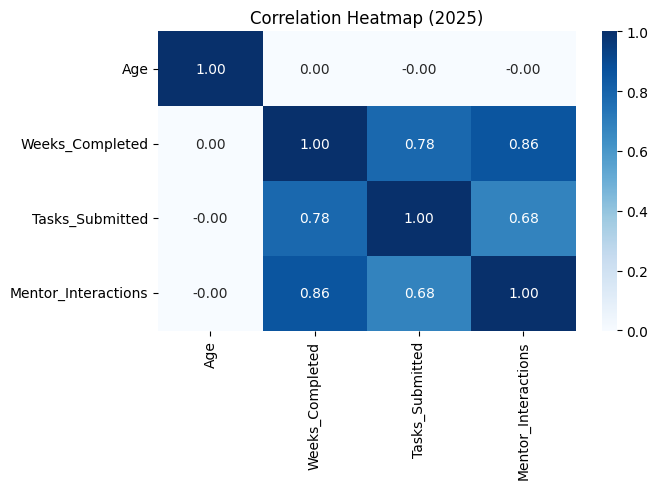

In [117]:
# Correlation Heatmap Visualization

# Create the heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

# Add chart title
plt.title("Correlation Heatmap (2025)")

# Adjust layout
plt.tight_layout()

# Save the figure
# plt.savefig(
#     "../outputs/figures/19_correlation_heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Display the chart
plt.show()

#### Observation

The correlation heatmap indicates strong positive relationships among the key internship performance variables. **Weeks Completed** has a strong positive correlation with **Mentor Interactions (0.86)** and **Tasks Submitted (0.78)**, while **Tasks Submitted** also shows a moderately strong positive correlation with **Mentor Interactions (0.68)**. In contrast, **Age** exhibits virtually no correlation with the other variables, suggesting that intern performance was independent of age in this dataset.

#### Business Insight

The strong positive relationships between **Weeks Completed**, **Tasks Submitted**, and **Mentor Interactions** suggest that consistent mentor engagement is associated with improved internship progress and task completion. Organizations should encourage regular mentor–intern communication and continuous progress monitoring to maximize internship completion and participant performance. Since **Age** shows no meaningful relationship with performance indicators, internship support strategies should focus on engagement and mentorship rather than participant age.

## Conclusion

This exploratory data analysis examined internship participation, demographic characteristics, departmental distribution, internship tracks, and key performance indicators using a synthetic dataset of 70,000 internship records for 2025.

The analysis revealed that internship enrollments peaked during the middle of the year, with Backend Development and Frontend Development attracting the highest number of participants. PHP, Node.js, React, and Flutter emerged as the most popular internship tracks. Most interns successfully completed the full eight-week internship, submitted the required tasks, and maintained regular mentor interactions, reflecting strong participant engagement and overall program success.

Additionally, the correlation analysis indicated strong positive relationships between weeks completed, tasks submitted, and mentor interactions, highlighting the importance of continuous mentorship in improving internship outcomes.

## Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

- Continue strengthening Backend Development and Frontend Development by allocating sufficient mentors and technical resources.
- Increase awareness and promotional activities for lower-participation departments and specialized internship tracks.
- Encourage greater female participation through targeted outreach and inclusive recruitment strategies.
- Monitor interns with low task submissions or limited mentor interactions to reduce dropout risk.
- Maintain regular mentor–intern communication, as higher mentor engagement is positively associated with internship completion and task submission.
- Expand institutional partnerships and promotional campaigns in underrepresented cities to improve geographical diversity.

## Final Remarks

This analysis demonstrates how exploratory data analysis can be used to understand internship participation, performance, and engagement. The insights generated from this study can support data-driven decision-making and help improve future internship programs.